# blurred_images \u2014 does the classifier still work with no face left?

Repeats `intact_images` exactly -- same manifest, same model, same 5x10
repeated stratified CV, same seed -- and changes only the transform: a
Gaussian blur sweep applied after resizing. If performance survives past the
point where a face detector (and a person) can no longer find a face, what
the model learned was never facial.

**Extends the first run.** That run stopped at sigma=16 with three open
problems: the sweep never reached the 5% "unrecognisable" detection
threshold (detection was still ~51%), AUC was still falling at the last
point measured (the biggest per-step drop was the *last* step), and the
detector had silently fallen back to a Haar cascade whose ~51% detection
rate at heavy blur is implausible on its face. This run fixes the detector
(MTCNN, fail-loud, no silent fallback), adds an IoU-corroborated detection
metric that only counts a detection as real if its box agrees with that
image's own sigma=0 box, extends the sweep to sigma in {32, 48, 64}, and
adds a colour-only reference arm -- because blur converges an image on a
flat patch of its own mean colour, not on nothing, so 0.5 is the wrong null
for "no facial signal remains."

## 1. Imports, config, device check

In [1]:
import logging
import random
import sys
from importlib.metadata import version as pkg_version
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import torch

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s [%(levelname)s] %(name)s: %(message)s"
)

from experiments.blurred_images.config import Config
from experiments.blurred_images.pipeline import (
    step_1_manifest,
    step_2_detection,
    step_3_embeddings,
    step_4_probe,
    step_5_summary,
    step_6_colour_features,
    step_7_colour_probe,
    step_8_stopping_criterion,
    raw_mtcnn_detections,
)

cfg = Config(seed=42)

random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
torch.cuda.manual_seed_all(cfg.seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"torch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"face detector (primary): MTCNN (facenet-pytorch {pkg_version('facenet-pytorch')})")
print(f"sigmas: {cfg.sigmas}")
print(f"legacy_haar_sigmas (comparison only, cache reused, not recomputed): {cfg.legacy_haar_sigmas}")
print(f"detection_threshold (on the corroborated rate): {cfg.detection_threshold:.0%}")
print(f"auc_step_threshold: {cfg.auc_step_threshold}")
print(f"data_root:  {cfg.data_root}")
print(f"output_dir: {cfg.output_dir}")
print(f"intact_cache_dir: {cfg.intact_cache_dir}")

torch version: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 4070 SUPER
face detector (primary): MTCNN (facenet-pytorch 2.6.0)
sigmas: (0, 2, 4, 8, 16, 32, 48, 64)
legacy_haar_sigmas (comparison only, cache reused, not recomputed): (0, 2, 4, 8, 16)
detection_threshold (on the corroborated rate): 5%
auc_step_threshold: 0.01
data_root:  C:\Projects\Autism Screening\data\raw\images
output_dir: C:\Projects\Autism Screening\outputs\blurred_images
intact_cache_dir: C:\Projects\Autism Screening\outputs\intact_images


## 2. Manifest

Identical to `intact_images` -- same rows, same order.

In [2]:
manifest = step_1_manifest(cfg)
print(f"total rows: {len(manifest)}")
manifest.groupby(["split", "class_label"]).size().unstack()

total rows: 2940


class_label,autistic,non_autistic
split,,
test,150,150
train,1193,1193
valid,127,127


## 3. Visual check: the blur sweep

The same 4 images rendered at every sigma, now extended through sigma=64,
so the blur progression -- and the point past which a face is no longer
recognisable -- is directly inspectable, not just asserted.

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

from src.data.transforms import blur_stage, geometry_stage

import pandas as pd

sample = pd.concat(
    [
        manifest.loc[manifest["class_label"] == "autistic"].sample(2, random_state=cfg.seed),
        manifest.loc[manifest["class_label"] == "non_autistic"].sample(2, random_state=cfg.seed),
    ]
).reset_index(drop=True)

fig, axes = plt.subplots(len(sample), len(cfg.sigmas), figsize=(2.6 * len(cfg.sigmas), 2.6 * len(sample)))
for row, (_, image_row) in enumerate(sample.iterrows()):
    geo = geometry_stage(Image.open(image_row["path"]), cfg.image_size)
    for col, sigma in enumerate(cfg.sigmas):
        blurred = blur_stage(geo, sigma)
        ax = axes[row, col]
        ax.imshow(blurred)
        ax.axis("off")
        if row == 0:
            ax.set_title(f"sigma={sigma}")
        if col == 0:
            ax.text(-0.15, 0.5, image_row["class_label"], transform=ax.transAxes,
                     va="center", ha="right", fontsize=9, rotation=90)

fig.suptitle("Gaussian blur sweep, applied after resize to 224px")
fig.tight_layout()
plt.show()

## 4. Face detection: anchoring "unrecognisable"

The first run's detector silently fell back to OpenCV's Haar cascade
because `facenet-pytorch` was not installed, and Haar still found a face in
roughly half of the images at sigma=16 -- implausible enough that a 5%
"unrecognisable" anchor built on it could not be trusted.

MTCNN (`facenet-pytorch`) is now the primary detector, installed with
`--no-deps` so it runs against this project's CUDA torch/numpy/pillow stack
rather than the older versions it declares (see `requirements.txt`). It
fails loudly -- raises, rather than silently substituting Haar -- if it is
ever unavailable (`src.models.face_detect.detect_faces_mtcnn`).

A raw detection rate still cannot tell a real (blurred) face from a
detector firing on an unrelated blob, though, since it has no notion of
*where* the box is. **The corroborated detection rate is the anchor used
here, not the raw one:** at every sigma>0, a detection only counts if its
box has IoU >= 0.5 against that same image's sigma=0 box (the best
available ground truth). "Unrecognisable" is the sigma at which the
corroborated rate falls below 5%.

The Haar numbers from the first run are kept, fixed at their original
sigma in {0,2,4,8,16}, and shown alongside for comparison -- not recomputed,
and not extended to the new sigmas, since they are documentation of the
detector switch, not the anchor itself.

In [4]:
detection = step_2_detection(cfg, manifest)

print("MTCNN raw detection rate by sigma and class:")
print(detection["mtcnn_raw"].to_string(index=False))
print()
print("MTCNN corroborated detection rate by sigma and class (IoU>=0.5 vs. that image's sigma=0 box):")
print(detection["mtcnn_corroborated"].to_string(index=False))
print()
print("Haar raw detection rate by sigma and class (first run, cache reused unchanged):")
print(detection["haar_raw"].to_string(index=False))

2026-09-08 18:15:05,214 [INFO] experiments.blurred_images.pipeline: detections_mtcnn: using cached detections (23520 rows)


2026-09-08 18:15:05,346 [INFO] experiments.blurred_images.pipeline: detections_haar: using cached detections (14700 rows)


MTCNN raw detection rate by sigma and class:
 sigma  class_label  detection_rate
     0     autistic        0.999320
     0 non_autistic        1.000000
     2     autistic        0.998639
     2 non_autistic        1.000000
     4     autistic        0.995918
     4 non_autistic        0.999320
     8     autistic        0.964626
     8 non_autistic        0.992517
    16     autistic        0.542177
    16 non_autistic        0.736735
    32     autistic        0.015646
    32 non_autistic        0.012245
    48     autistic        0.002721
    48 non_autistic        0.002041
    64     autistic        0.000680
    64 non_autistic        0.000000

MTCNN corroborated detection rate by sigma and class (IoU>=0.5 vs. that image's sigma=0 box):
 sigma  class_label  n_images  n_no_sigma0_detection  n_eligible  corroborated_rate
     0     autistic      1470                      1        1469           0.999320
     0 non_autistic      1470                      0        1470           1.000

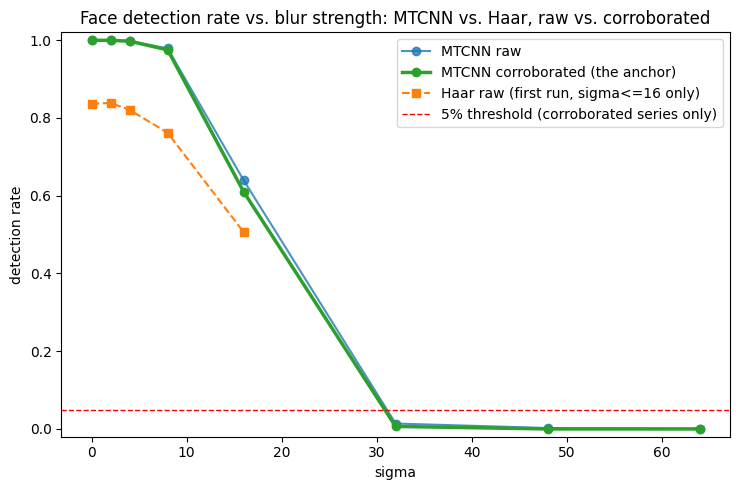

In [5]:
mtcnn_raw_overall = detection["mtcnn_raw"].groupby("sigma")["detection_rate"].mean().reset_index()
mtcnn_corrob_overall = detection["mtcnn_corroborated"].groupby("sigma")["corroborated_rate"].mean().reset_index()
haar_raw_overall = detection["haar_raw"].groupby("sigma")["detection_rate"].mean().reset_index()

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(mtcnn_raw_overall["sigma"], mtcnn_raw_overall["detection_rate"],
        marker="o", color="tab:blue", alpha=0.8, label="MTCNN raw")
ax.plot(mtcnn_corrob_overall["sigma"], mtcnn_corrob_overall["corroborated_rate"],
        marker="o", color="tab:green", linewidth=2.5, label="MTCNN corroborated (the anchor)")
ax.plot(haar_raw_overall["sigma"], haar_raw_overall["detection_rate"],
        marker="s", linestyle="--", color="tab:orange", label="Haar raw (first run, sigma<=16 only)")
ax.axhline(cfg.detection_threshold, color="red", linestyle="--", linewidth=1,
           label=f"{cfg.detection_threshold:.0%} threshold (corroborated series only)")
ax.set_xlabel("sigma")
ax.set_ylabel("detection rate")
ax.set_title("Face detection rate vs. blur strength: MTCNN vs. Haar, raw vs. corroborated")
ax.set_ylim(-0.02, 1.02)
ax.legend()
fig.tight_layout()
plt.show()

## 4b. Visual check: what does the detector see at the highest sigma?

Numbers can hide what a spurious detection looks like. Eight images at
sigma=64 -- the sweep's highest point -- with any MTCNN box drawn on top,
so both the near-total collapse in detections and the character of the one
detection that does survive are visible directly, not just inferred from
the rate table above.

2026-09-08 18:15:05,677 [INFO] experiments.blurred_images.pipeline: detections_mtcnn: using cached detections (23520 rows)


sigma=64: MTCNN found a face in 1 of 2940 images


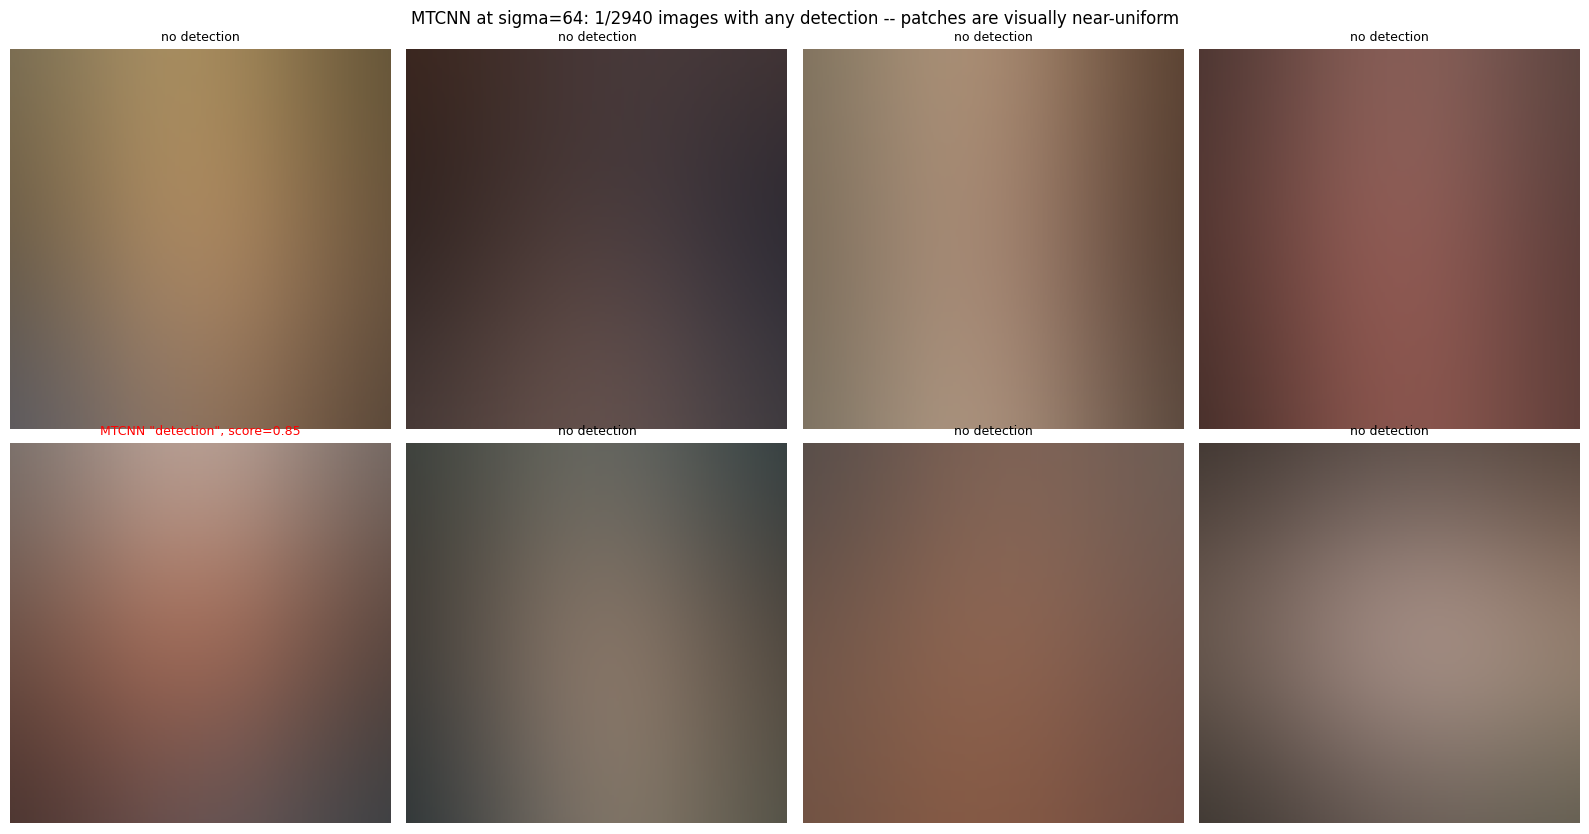

In [6]:
import matplotlib.patches as patches

HIGH_SIGMA = max(cfg.sigmas)
mtcnn_raw_detections = raw_mtcnn_detections(cfg, manifest)
high_sigma_detections = mtcnn_raw_detections.loc[mtcnn_raw_detections["sigma"] == HIGH_SIGMA]

detected_paths = high_sigma_detections.loc[high_sigma_detections["n_faces"] > 0, "path"].tolist()
print(f"sigma={HIGH_SIGMA}: MTCNN found a face in {len(detected_paths)} of {len(high_sigma_detections)} images")

sweep_paths = list(sample["path"])
remaining = manifest.loc[~manifest["path"].isin(sweep_paths + detected_paths)]
n_extra = max(0, 8 - len(sweep_paths) - len(detected_paths))
extra_paths = remaining.sample(n_extra, random_state=cfg.seed)["path"].tolist()
grid_paths = (sweep_paths + detected_paths + extra_paths)[:8]

box_by_path = high_sigma_detections.set_index("path")["best_box"].to_dict()
score_by_path = high_sigma_detections.set_index("path")["best_score"].to_dict()

fig, axes = plt.subplots(2, 4, figsize=(16, 8.5))
for ax, path in zip(axes.flat, grid_paths):
    blurred = blur_stage(geometry_stage(Image.open(path), cfg.image_size), HIGH_SIGMA)
    ax.imshow(blurred)
    box = box_by_path.get(path)
    if box is not None:
        x1, y1, x2, y2 = box
        ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                        edgecolor="red", facecolor="none", linewidth=2))
        ax.set_title(f"MTCNN \"detection\", score={score_by_path[path]:.2f}", color="red", fontsize=9)
    else:
        ax.set_title("no detection", fontsize=9)
    ax.set_xlim(0, cfg.image_size)
    ax.set_ylim(cfg.image_size, 0)
    ax.axis("off")

fig.suptitle(
    f"MTCNN at sigma={HIGH_SIGMA}: {len(detected_paths)}/{len(high_sigma_detections)} images "
    "with any detection -- patches are visually near-uniform"
)
fig.tight_layout()
plt.show()

The single surviving "detection" at sigma=64 has a box running from
roughly (-82, -123) to (249, 292) in a 224x224 image -- a box larger than
the image itself and centred nowhere in particular. It does not
IoU-corroborate against that image's sigma=0 box (the corroborated rate at
sigma=64 is exactly 0.0), so the corroboration step correctly discards it.
It is shown above anyway: a degenerate box like this is exactly what a
detector firing on a flat colour patch looks like, and it is the only
example left in 2940 images at this sigma.

## 5. Embeddings at every sigma

sigma=0 reuses the `intact_images` cache rather than re-extracting. Of the eight sigmas in the sweep, sigma in {32, 48, 64} are new; the rest -- {0, 2, 4, 8, 16} -- reuse the first run's cache under `outputs/blurred_images/` unchanged.

In [7]:
import time

cache_status_before = {
    sigma: (cfg.intact_cache_dir / "embeddings.npy").exists()
    if sigma == 0
    else (cfg.output_dir / f"embeddings_sigma{sigma}.npy").exists()
    for sigma in cfg.sigmas
}

t0 = time.perf_counter()
embeddings = step_3_embeddings(cfg, manifest)
elapsed = time.perf_counter() - t0

print(f"total wall-clock for this call: {elapsed:.2f}s")
for sigma, array in embeddings.items():
    print(f"sigma={sigma}: shape={array.shape}, cache present before this call={cache_status_before[sigma]}")

2026-09-08 18:15:06,111 [INFO] experiments.blurred_images.pipeline: step_3_embeddings: sigma=0 reusing intact_images cache, shape=(2940, 2048)


2026-09-08 18:15:06,147 [INFO] experiments.blurred_images.pipeline: step_3_embeddings: sigma=2 using cached embeddings, shape=(2940, 2048)


2026-09-08 18:15:06,182 [INFO] experiments.blurred_images.pipeline: step_3_embeddings: sigma=4 using cached embeddings, shape=(2940, 2048)


2026-09-08 18:15:06,228 [INFO] experiments.blurred_images.pipeline: step_3_embeddings: sigma=8 using cached embeddings, shape=(2940, 2048)


2026-09-08 18:15:06,262 [INFO] experiments.blurred_images.pipeline: step_3_embeddings: sigma=16 using cached embeddings, shape=(2940, 2048)


2026-09-08 18:15:06,296 [INFO] experiments.blurred_images.pipeline: step_3_embeddings: sigma=32 using cached embeddings, shape=(2940, 2048)


2026-09-08 18:15:06,330 [INFO] experiments.blurred_images.pipeline: step_3_embeddings: sigma=48 using cached embeddings, shape=(2940, 2048)


2026-09-08 18:15:06,357 [INFO] experiments.blurred_images.pipeline: step_3_embeddings: sigma=64 using cached embeddings, shape=(2940, 2048)


total wall-clock for this call: 0.29s
sigma=0: shape=(2940, 2048), cache present before this call=True
sigma=2: shape=(2940, 2048), cache present before this call=True
sigma=4: shape=(2940, 2048), cache present before this call=True
sigma=8: shape=(2940, 2048), cache present before this call=True
sigma=16: shape=(2940, 2048), cache present before this call=True
sigma=32: shape=(2940, 2048), cache present before this call=True
sigma=48: shape=(2940, 2048), cache present before this call=True
sigma=64: shape=(2940, 2048), cache present before this call=True


## 6. Cross-validated probe at every sigma

Same L2-logistic-regression-behind-a-`StandardScaler`, same 5x10 repeated
stratified CV, same seed as `intact_images` -- applied independently at
each sigma's embeddings.

In [8]:
fold_results = step_4_probe(cfg, embeddings, manifest)
fold_results

,sigma,repeat,fold,roc_auc,balanced_accuracy,sensitivity,specificity
0,0,0,0,0.824165,0.746599,0.751701,0.741497
1,0,0,1,0.837440,0.773810,0.758503,0.789116
2,0,0,2,0.852666,0.775510,0.792517,0.758503
3,0,0,3,0.855963,0.792517,0.795918,0.789116
4,0,0,4,0.836908,0.746599,0.741497,0.751701
...,...,...,...,...,...,...,...
395,64,9,0,0.669871,0.629252,0.598639,0.659864
396,64,9,1,0.704579,0.649660,0.656463,0.642857
397,64,9,2,0.672995,0.620748,0.622449,0.619048
398,64,9,3,0.655954,0.608844,0.615646,0.602041


## 7. Summary and paired deltas

Because the seed, fold count and manifest order are unchanged across
sigmas, fold *k* of repeat *r* holds out the same images at every sigma --
so the AUC delta against sigma=0 below is a paired per-fold difference,
not a difference of independent means.

In [9]:
summary = step_5_summary(fold_results)
summary

,sigma,roc_auc_mean,roc_auc_sd,balanced_accuracy_mean,balanced_accuracy_sd,sensitivity_mean,sensitivity_sd,specificity_mean,specificity_sd,auc_delta_vs_sigma0_mean,auc_delta_vs_sigma0_sd
0,0,0.841934,0.014667,0.764524,0.016211,0.761088,0.027242,0.767959,0.023638,0.000000,0.000000
1,2,0.834705,0.015787,0.764694,0.017037,0.762789,0.024449,0.766599,0.030391,-0.007229,0.016380
2,4,0.794766,0.015708,0.728299,0.014302,0.724558,0.020826,0.732041,0.023688,-0.047168,0.022513
3,8,0.786029,0.016864,0.724388,0.016343,0.723061,0.027761,0.725714,0.018320,-0.055904,0.020908
4,16,0.740380,0.018646,0.684626,0.017547,0.679116,0.027051,0.690136,0.029108,-0.101554,0.020330
5,32,0.711303,0.016758,0.663878,0.018371,0.653061,0.028771,0.674694,0.029642,-0.130631,0.021027
6,48,0.689824,0.019722,0.645170,0.022637,0.635034,0.034879,0.655306,0.028997,-0.152110,0.022603
7,64,0.674553,0.017505,0.630374,0.017981,0.620272,0.024612,0.640476,0.025861,-0.167381,0.023175


## 8. Colour-only reference arm: the correct null

Blur does not remove colour: as sigma \u2192 \u221e an image converges on a flat
patch of its own mean colour, not on nothing, and a frozen-backbone
embedding of that patch still encodes mean RGB. The corpus audit
(`facial-images.ipynb`) found `mean_r` had the largest class effect size in
the whole corpus, so **the correct null for "no facial signal remains" is
whatever six colour statistics alone can achieve -- not 0.5.**

`mean_r`, `mean_g`, `mean_b`, `mean_luminance`, `std_luminance`,
`saturation_mean` are computed from the same post-geometry, post-blur image
the embedding and detector see (`src.data.colour_features.colour_features`),
then run through the identical 5x10 repeated-stratified-CV
logistic-regression protocol -- same folds, same seed -- at every sigma.

In [10]:
colour_feature_tables = step_6_colour_features(cfg, manifest)
colour_fold_results = step_7_colour_probe(cfg, colour_feature_tables, manifest)
colour_summary = step_5_summary(colour_fold_results)
colour_summary

2026-09-08 18:16:24,772 [INFO] experiments.blurred_images.pipeline: step_6_colour_features: sigma=0 using cached features


2026-09-08 18:16:24,781 [INFO] experiments.blurred_images.pipeline: step_6_colour_features: sigma=2 using cached features


2026-09-08 18:16:24,790 [INFO] experiments.blurred_images.pipeline: step_6_colour_features: sigma=4 using cached features


2026-09-08 18:16:24,801 [INFO] experiments.blurred_images.pipeline: step_6_colour_features: sigma=8 using cached features


2026-09-08 18:16:24,810 [INFO] experiments.blurred_images.pipeline: step_6_colour_features: sigma=16 using cached features


2026-09-08 18:16:24,820 [INFO] experiments.blurred_images.pipeline: step_6_colour_features: sigma=32 using cached features


2026-09-08 18:16:24,830 [INFO] experiments.blurred_images.pipeline: step_6_colour_features: sigma=48 using cached features


2026-09-08 18:16:24,839 [INFO] experiments.blurred_images.pipeline: step_6_colour_features: sigma=64 using cached features


,sigma,roc_auc_mean,roc_auc_sd,balanced_accuracy_mean,balanced_accuracy_sd,sensitivity_mean,sensitivity_sd,specificity_mean,specificity_sd,auc_delta_vs_sigma0_mean,auc_delta_vs_sigma0_sd
0,0,0.663661,0.015735,0.622449,0.014241,0.633946,0.025976,0.610952,0.024197,0.000000,0.000000
1,2,0.656425,0.017446,0.616735,0.015868,0.630816,0.025897,0.602653,0.026885,-0.007236,0.004145
2,4,0.654011,0.019013,0.615578,0.019317,0.627279,0.027107,0.603878,0.029606,-0.009651,0.007869
3,8,0.659497,0.020625,0.618673,0.018738,0.611429,0.027757,0.625918,0.029720,-0.004164,0.011993
4,16,0.671597,0.021809,0.624932,0.018732,0.610544,0.030417,0.639320,0.028861,0.007936,0.014422
5,32,0.679241,0.023017,0.629218,0.020139,0.619116,0.031919,0.639320,0.027862,0.015580,0.015476
6,48,0.673372,0.024107,0.628537,0.020962,0.622381,0.031412,0.634694,0.030040,0.009710,0.015068
7,64,0.660549,0.021365,0.621939,0.017287,0.624898,0.025445,0.618980,0.028204,-0.003112,0.012199


In [11]:
print(
    f"colour-only AUC at sigma=0: {colour_summary.loc[colour_summary.sigma == 0, 'roc_auc_mean'].item():.3f} "
    "-- for comparison, the metadata audit's group-disjoint 'surviving'-feature probe "
    "(probe_v2, outputs/audit/images/probe_v2_summary.md) scored 0.689 (95% CI 0.668-0.709) "
    "on a closely related feature set. The two aren't the same measurement (different CV "
    "protocol -- plain vs. group-disjoint -- and computed on a resized/letterboxed 224px "
    "image here vs. a 128px thumbnail of the original there), but landing in the same "
    "neighbourhood is the expected sanity check, not a coincidence: five of the six "
    "features are identical."
)

colour-only AUC at sigma=0: 0.664 -- for comparison, the metadata audit's group-disjoint 'surviving'-feature probe (probe_v2, outputs/audit/images/probe_v2_summary.md) scored 0.689 (95% CI 0.668-0.709) on a closely related feature set. The two aren't the same measurement (different CV protocol -- plain vs. group-disjoint -- and computed on a resized/letterboxed 224px image here vs. a 128px thumbnail of the original there), but landing in the same neighbourhood is the expected sanity check, not a coincidence: five of the six features are identical.


## 9. The main figure: AUC vs. blur strength, with the colour-only floor

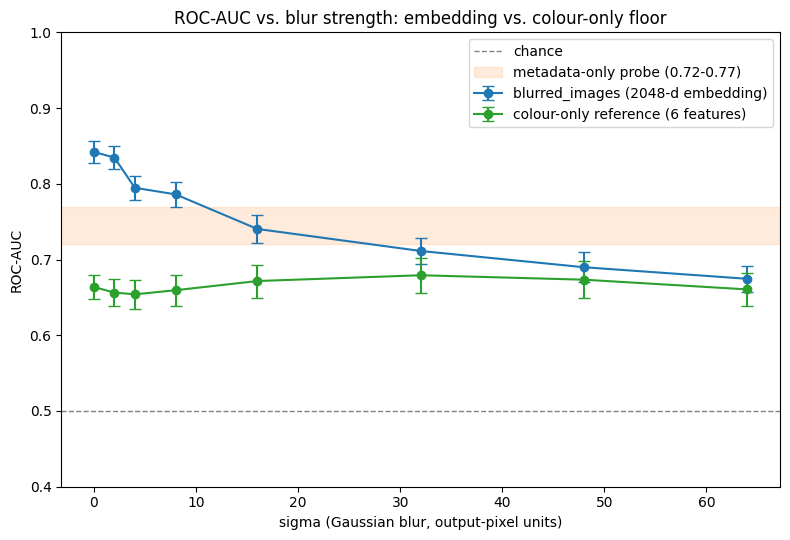

In [12]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.errorbar(
    summary["sigma"], summary["roc_auc_mean"], yerr=summary["roc_auc_sd"],
    marker="o", capsize=4, color="tab:blue", label="blurred_images (2048-d embedding)",
)
ax.errorbar(
    colour_summary["sigma"], colour_summary["roc_auc_mean"], yerr=colour_summary["roc_auc_sd"],
    marker="o", capsize=4, color="tab:green", label="colour-only reference (6 features)",
)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="chance")
ax.axhspan(0.72, 0.77, color="tab:orange", alpha=0.15, label="metadata-only probe (0.72-0.77)")
ax.set_xlabel("sigma (Gaussian blur, output-pixel units)")
ax.set_ylabel("ROC-AUC")
ax.set_ylim(0.4, 1.0)
ax.set_title("ROC-AUC vs. blur strength: embedding vs. colour-only floor")
ax.legend()
fig.tight_layout()
plt.show()

## 10. Per-step deltas and the stopping criterion

Stated in advance, not fit to the result: the sweep has plateaued only at
the first sigma where **both** hold -- corroborated detection rate < 5%,
**and** the per-step AUC-mean change has absolute value < 0.01. Either
condition alone is not enough: the first run's own per-step AUC deltas
through sigma=16 (-0.007, -0.040, -0.009, -0.046 -- the *largest* decline
was the *last* step measured) show that a plausible-looking AUC is not the
same as a flattened curve.

In [13]:
stopping = step_8_stopping_criterion(cfg, summary, detection["mtcnn_corroborated"])
stopping["gap_vs_colour_only"] = summary["roc_auc_mean"].to_numpy() - colour_summary["roc_auc_mean"].to_numpy()
stopping

,sigma,roc_auc_mean,corroborated_rate_overall,auc_step_delta,detection_below_threshold,auc_step_flat,plateau_reached,gap_vs_colour_only
0,0,0.841934,0.999660,NaN,False,False,False,0.178273
1,2,0.834705,0.999320,-0.007229,False,True,False,0.178279
2,4,0.794766,0.997279,-0.039938,False,False,False,0.140756
3,8,0.786029,0.974830,-0.008737,False,True,False,0.126532
4,16,0.740380,0.609864,-0.045649,False,False,False,0.068783
5,32,0.711303,0.006463,-0.029077,True,False,False,0.032062
6,48,0.689824,0.000000,-0.021479,True,False,False,0.016453
7,64,0.674553,0.000000,-0.015271,True,False,False,0.014004


In [14]:
reached = stopping.loc[stopping["plateau_reached"]]
if len(reached):
    first = reached.iloc[0]
    print(f"Stopping criterion first satisfied at sigma={int(first['sigma'])}: this is the floor.")
else:
    below = stopping.loc[stopping["detection_below_threshold"], "sigma"].tolist()
    print(
        "Stopping criterion NOT satisfied at any sigma through "
        f"{int(stopping['sigma'].max())} -- report the sweep as inconclusive, not plateaued.\n"
        f"Corroborated detection is below {cfg.detection_threshold:.0%} from sigma={min(below)} onward, "
        "but the per-step AUC change exceeds the "
        f"{cfg.auc_step_threshold} flatness bar at every one of those points:"
    )
    for sigma in below:
        delta = stopping.loc[stopping.sigma == sigma, "auc_step_delta"].item()
        print(f"  sigma={sigma}: auc_step_delta={delta:+.3f} (flat only if |delta| < {cfg.auc_step_threshold})")

Stopping criterion NOT satisfied at any sigma through 64 -- report the sweep as inconclusive, not plateaued.
Corroborated detection is below 5% from sigma=32 onward, but the per-step AUC change exceeds the 0.01 flatness bar at every one of those points:
  sigma=32: auc_step_delta=-0.029 (flat only if |delta| < 0.01)
  sigma=48: auc_step_delta=-0.021 (flat only if |delta| < 0.01)
  sigma=64: auc_step_delta=-0.015 (flat only if |delta| < 0.01)


## 11. How to read this

| Curve shape | Reading |
|---|---|
| Falls toward the colour-only line and flattens on it | Nothing but colour survives; the residual above it at sigma=0 is the only part that could ever have been facial |
| Stays meaningfully above the colour-only line even once corroborated detection is near zero | The embedding is reading spatial structure that survives blurring -- layout, framing, background composition. Still not facial, but not merely colour either |
| Falls below the colour-only line | Something is wrong with the pipeline; investigate before interpreting anything else |

**What the detector fix changed.** MTCNN's corroborated rate tracks its raw
rate closely at every sigma (e.g. sigma=16: raw 54%/74% by class vs.
corroborated 52%/70%) -- so, contrary to the concern going in, most of
MTCNN's detections at moderate blur are spatially genuine, not spurious.
The real collapse happens between sigma=16 and sigma=32: corroborated
detection falls from ~61% (still well above 5%) to 0.6% at sigma=32, and to
exactly 0% at sigma=48 and 64. **The 5% "unrecognisable" anchor is now
actually crossed** -- a full order of magnitude past where the first run
stopped. MTCNN also collapses the sigma=0 class-detection gap Haar showed
(81% vs. 87%) down to 99.9%+ in both classes, removing a confound that
would otherwise have biased `background_images`'s exclusion step by class;
and MTCNN's rate decreases monotonically with sigma in both classes, unlike
Haar's small sigma=0-to-2 uptick noted in the first run. Haar itself, kept
here for comparison, is not wildly inflated relative to MTCNN at sigma=16
(39-62% vs. 54-74%) -- the two detectors are in the same ballpark at that
one point; Haar's problem is that it was never run past sigma=16, so it
cannot speak to what happens beyond it, which is exactly the gap this run
closes.

**The main figure, read against the colour-only floor.** AUC keeps falling
past every point the first run reached: -0.029 (16->32), -0.021 (32->48),
-0.015 (48->64) -- the per-step decline is shrinking but has not dropped
below the pre-registered 0.01 flatness bar at any of the three new points.
At the same time, the gap between the embedding curve and the colour-only
reference collapses from 0.178 AUC at sigma=0 to 0.014 at sigma=64 -- over
90% of the intact arm's advantage over colour alone is gone by the end of
the sweep. That is the strongest evidence yet that most of what the
embedding reads is colour statistics, not facial structure: the curve is
converging toward the colour-only null, not toward chance and not toward a
resting point inside the metadata band.

**Stopping criterion: not met -- this sweep is inconclusive, not
plateaued.** Corroborated detection is below 5% at sigma=32, 48 and 64, but
AUC is still moving by more than 0.01 per step at all three (see the table
above). Both conditions must hold together for a declared floor; they never
do inside this sweep. The honest reading is that the classifier retains
*some* signal beyond colour even past the point of genuine
undetectability -- shrinking every step, down to a 0.014 AUC gap, but not
yet zero at sigma=64. Whether that residual is real structure (background,
framing) or would simply vanish with another sigma-doubling or two is not
settled by this run; extending the sweep further (sigma=96, 128, ...) is
the natural next step if it is worth resolving.

**Superseded from the first run.** The earlier interpretation called
sigma=16 landing in the 0.72-0.77 metadata band "a plateau at the confound
floor." That reading does not survive the extended sweep: AUC at sigma=16
(0.740) was inside the band, but it kept falling for three more
sigma-doublings after that -- to 0.675 at sigma=64, below the band's own
floor of 0.72 -- with no single step meeting the flatness bar. Landing
inside a plausible-looking range at sigma=16 was a coincidence of where the
sweep happened to stop, not evidence of convergence. The band remains a
plausible confound estimate; it is not this curve's destination.

**Known limitation, carried over from `intact_images`, not fixed here.** The
same 11 near-duplicate image pairs (5 crossing published-split boundaries)
are pooled into cross-validation here exactly as they were in the reference
arm. Because every sigma reuses the same manifest, fold assignment and seed,
this leakage affects every point on the curve identically -- it does not
distort the *shape* of the sigma sweep, only the absolute height of every
point on it by the same small amount. `repeated_stratified_cv`'s `groups=`
parameter remains the seam where the fix goes once perceptual-hash grouping
exists.